In [ ]:
import scanpy as sc
import cell2location
from cell2location.utils.filtering import filter_genes

reference = sc.read_h5ad('/nfs/users/nfs_d/dp26/nfs_storage/Megagut/downsampled_5000_each_celltype_v1_hgca_all_lineages_v1.h5ad')

/nfs/team205/dp26/conda_env/cell2location_cuda118_torch22/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
reference

In [3]:
# reference.var['SYMBOL'] = reference.var.index
# rename 'GeneID-2' as necessary for your data
# reference.var.set_index('gene_ids', drop=True, inplace=True)

In [4]:
# reference.X = reference.layers['counts']

/nfs/team205/dp26/conda_env/cell2location_cuda118_torch22/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


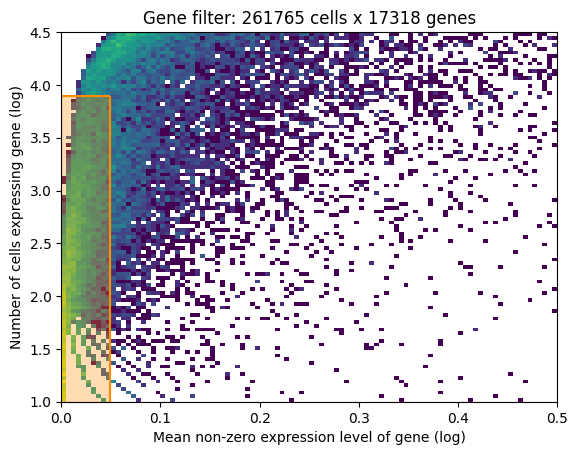

In [5]:
selected = filter_genes(reference, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

In [6]:
# filter the object
reference = reference[:, selected].copy()

In [ ]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=reference, 
                        # 10X reaction / sample / batch
                        batch_key='sample_id', 
                        # cell type, covariate used for constructing signatures
                        labels_key='hgca_celltype_v1', 
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                        categorical_covariate_keys=['donor_id','assay']
                       )

In [ ]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(reference) 

# view anndata_setup as a sanity check
mod.view_anndata_setup()

In [ ]:
mod.train(max_epochs=250)

In [7]:
results_folder = '/nfs/users/nfs_d/dp26/nfs_storage/Megagut/cell2location_run/result_hgca_scRNAseq/'

# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/reference_signatures_hgca_celltype_v1'

In [8]:
mod = cell2location.models.RegressionModel.load(f"{ref_run_name}", reference)

INFO     File                                                                                                      
         /nfs/users/nfs_d/dp26/nfs_storage/Megagut/cell2location_run/result_hgca_scRNAseq//reference_signatures_hgc
         a_celltype_v1/model.pt already downloaded                                                                 


/nfs/team205/dp26/conda_env/cell2location_cuda118_torch22/lib/python3.10/site-packages/scvi/data/fields/_dataframe_field.py:224: UserWarning: Category 478 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/nfs/team205/dp26/conda_env/cell2location_cuda118_torch22/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:72: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA A100-SXM4-80GB MIG 1g.10gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#to

Epoch 1/76:   1%|▏         | 1/76 [00:00<00:35,  2.12it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/76:   1%|▏         | 1/76 [00:00<00:36,  2.05it/s, v_num=1]


In [9]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
reference = mod.export_posterior(
    reference, sample_kwargs={'num_samples': 800, 'batch_size': 2000}
)


Sampling global variables, sample: 100%|██████████| 799/799 [01:02<00:00, 12.87it/s]


In [10]:
# Save anndata object with results
adata_file = f"{ref_run_name}/sc.h5ad"

In [11]:
reference.write_h5ad(adata_file)